In [1]:
!pip install scikit-learn

In [2]:
from sklearn.datasets import load_breast_cancer

# load dataset
cancer = load_breast_cancer()

print(type(cancer))

<class 'sklearn.utils._bunch.Bunch'>


In [3]:
import pandas as pd

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df.shape

(569, 31)

In [5]:
X = df.drop('target', axis=1)
y = df['target']

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(569, 2)


In [8]:
pca.explained_variance_ratio_

array([0.44272026, 0.18971182])

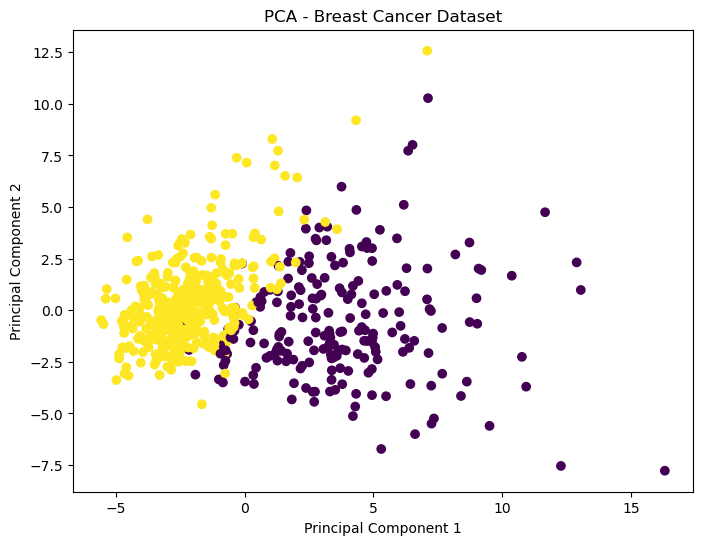

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Breast Cancer Dataset")
plt.show()

In [10]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2'],
    index=X.columns
)

loadings['importance'] = loadings['PC1'].abs() + loadings['PC2'].abs()

loadings.sort_values('importance', ascending=False).head(10)

,PC1,PC2,importance
mean radius,0.218902,-0.233857,0.452760
mean area,0.220995,-0.231077,0.452072
worst radius,0.227997,-0.219866,0.447863
worst area,0.224871,-0.219352,0.444222
mean perimeter,0.227537,-0.215181,0.442719
worst perimeter,0.236640,-0.199878,0.436518
mean fractal dimension,0.064363,0.366575,0.430939
worst fractal dimension,0.131784,0.275339,0.407123
compactness error,0.170393,0.232716,0.403109
mean compactness,0.239285,0.151892,0.391177


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9912280701754386



I utilized Principal Component Analysis (PCA) on the breast cancer dataset to reduce the number of medical features from 30 to 2 main components. The PCA projection preserved a significant portion of the essential information inside the dataset.

The logistic regression model trained on only the two PCA components achieved nearly 99% accuracy, indicating that the essential diagnostic information remained intact post-dimensionality reduction.

This means that a few primary variables (principal components) can give a good summary of the information and yet be able to tell if a tumor is cancerous or not. So, PCA was able to determine the dataset's most essential traits.